In [1]:

!pip install pandas numpy scikit-learn lightgbm xgboost shap imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------

In [13]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, confusion_matrix
import shap
import joblib

In [14]:

train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (1296675, 23)
Test shape: (555719, 23)


In [15]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [17]:

def apply_feature_engineering(df):
    df = df.copy()
    
    # Time features
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    
   
    df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2)
    
    
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    
    
    cols_to_drop = ['Unnamed: 0', 'trans_date_trans_time', 'dob', 'cc_num', 
                    'first', 'last', 'street', 'city', 'state', 'zip', 'job', 'trans_num']
    
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    
 
    for col in ['category', 'gender', 'merchant']:
        if col in df.columns:
            df[col] = df[col].astype('category')
            
    return df



In [18]:
train_eng = apply_feature_engineering(train_df)
test_eng = apply_feature_engineering(test_df)

In [19]:
X_train = train_eng.drop(columns=['is_fraud'])
y_train = train_eng['is_fraud']

X_test = test_eng.drop(columns=['is_fraud'])
y_test = test_eng['is_fraud']

In [20]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=5, 
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2840
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005789 -> initscore=-5.146050
[LightGBM] [Info] Start training from score -5.146050


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:

y_pred_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.55
y_pred = (y_pred_proba > threshold).astype(int)

print("--- Performance Metrics ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Performance Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.76      0.77      0.77      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.89      0.88    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC Score: 0.9936500745825245


In [23]:
import joblib

# Model save karo
joblib.dump(model, 'razorpay_risk_model.pkl')
print("Model saved successfully as razorpay_risk_model.pkl!")

Model saved successfully as razorpay_risk_model.pkl!


In [24]:
!pip install shap matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [25]:
import shap
import matplotlib.pyplot as plt

# 1. LightGBM ke liye Explainer banao
explainer = shap.TreeExplainer(model)

# 2. Test data par SHAP values calculate karo (Fast computation ke liye 1000 samples use kar rahe hain)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer(X_test_sample)

print("SHAP values generated successfully!")

SHAP values generated successfully!


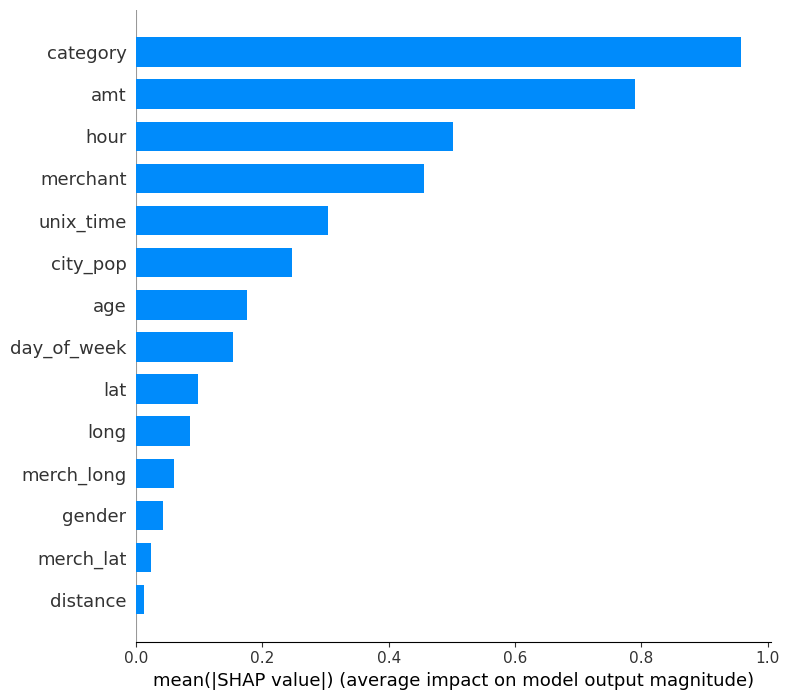

In [26]:
# Summary Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

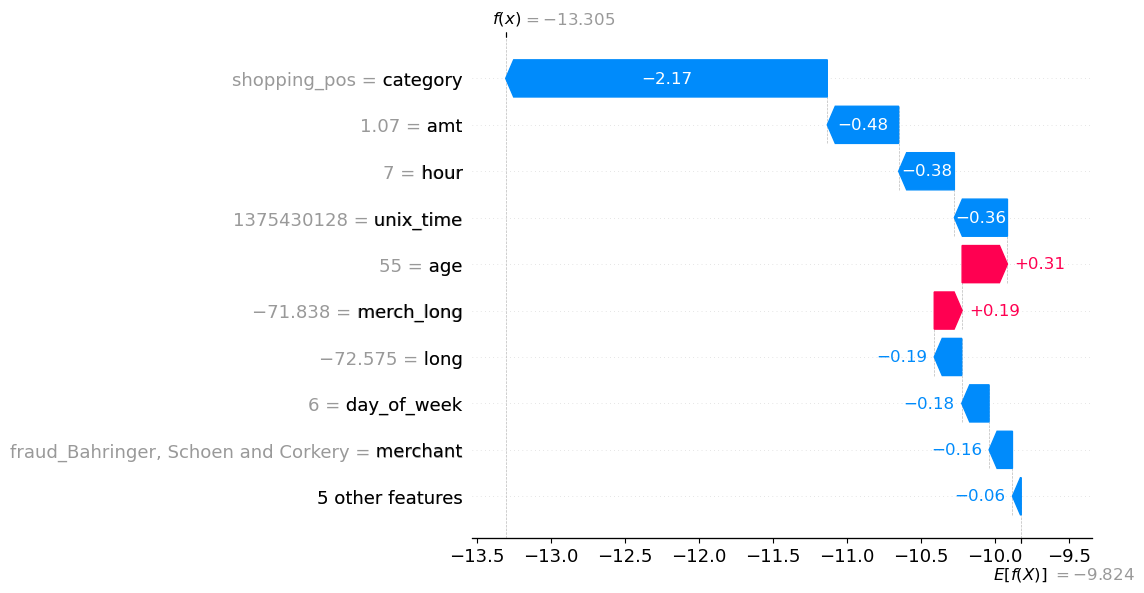

In [27]:
# Select 1 specific high-risk transaction sample
sample_index = 0

# Single prediction SHAP plot
shap.plots.waterfall(shap_values[sample_index])